In [8]:
from sklearn.datasets import fetch_openml

# Carregue o conjunto de dados MNIST
mnist = fetch_openml('mnist_784')

# Separe os recursos e rótulos
X = mnist.data
y = mnist.target

In [9]:
# Divida o conjunto de dados em conjuntos de treinamento e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.tree import DecisionTreeClassifier
# Crie o modelo de Árvore de Decisão
tree_clf = DecisionTreeClassifier(max_depth=20,min_samples_leaf=1,min_samples_split=6,random_state=42)

# Treine o modelo de Árvore de Decisão
tree_clf.fit(X_train, y_train)

# Faça previsões no conjunto de teste
y_pred = tree_clf.predict(X_test)

# função auxiliar em Python para plotar as previsões em comparação com os valores reais do conjunto de dados MNIST:


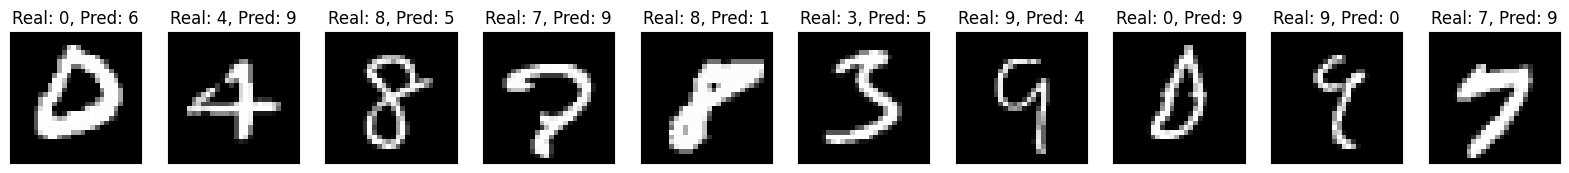

In [11]:
import numpy as np
import matplotlib.pyplot as plt
 
misclassified_indices = np.where(y_pred != y_test)[0]
n_samples = min(len(misclassified_indices), 10)

fig, axes = plt.subplots(nrows=1, ncols=n_samples, figsize=(20, 4))

for i, index in enumerate(misclassified_indices[:n_samples]):
    axes[i].imshow(X_test.iloc[index].values.reshape(28, 28), cmap='gray')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title(f"Real: {y_test.iloc[index]}, Pred: {y_pred[index]}")
    
plt.show()


(28, 28) float64 2
new (784,) float64 1


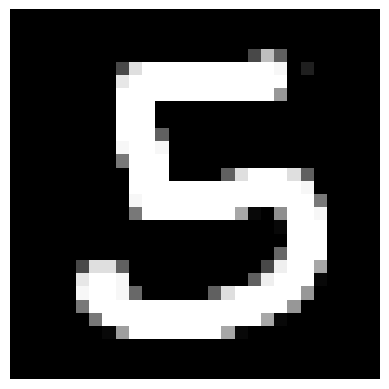

In [12]:
from PIL import Image 
import numpy as np
img = Image.open("image5.png") # This returns an image object
gray_img = img.convert("L")
plt.axis('off')
plt.imshow(gray_img, cmap='gray')
plt.savefig("gray_pic.jpg")

img = np.asarray(gray_img,float) # convert it to ndarray
print(img.shape, img.dtype, img.ndim)

new = img.reshape(784,)

print('new',new.shape, new.dtype, new.ndim)



In [13]:
print(tree_clf.predict_proba([new]))

[[0.         0.         0.         0.33333333 0.         0.66666667
  0.         0.         0.         0.        ]]


c:\Users\babib\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Precisão do modelo de Árvore de Decisão: 0.8739285714285714
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1343
           1       0.94      0.95      0.95      1600
           2       0.84      0.84      0.84      1380
           3       0.85      0.84      0.85      1433
           4       0.85      0.89      0.87      1295
           5       0.84      0.82      0.83      1273
           6       0.89      0.90      0.90      1396
           7       0.91      0.91      0.91      1503
           8       0.84      0.79      0.81      1357
           9       0.85      0.84      0.84      1420

    accuracy                           0.87     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.87      0.87      0.87     14000



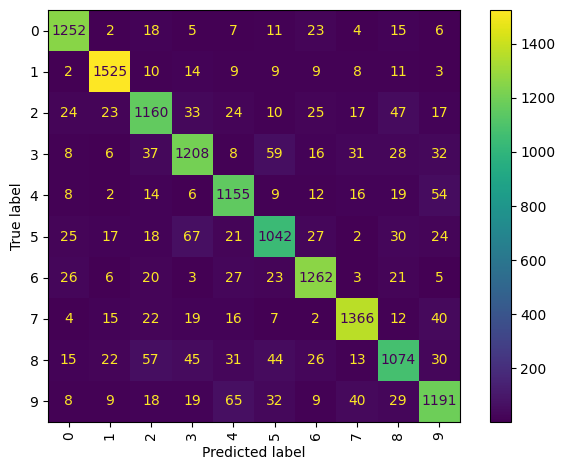

In [14]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Avalie a precisão do modelo de Árvore de Decisão
accuracy = accuracy_score(y_test, y_pred)
print("Precisão do modelo de Árvore de Decisão:", accuracy)
class_names = sorted(list(mnist.target.unique()))
print(class_names)

print(classification_report(y_test, y_pred, target_names=class_names))
ConfusionMatrixDisplay.from_estimator(
    tree_clf, X_test, y_test, display_labels= class_names, xticks_rotation="vertical"
)
plt.tight_layout()
plt.show()


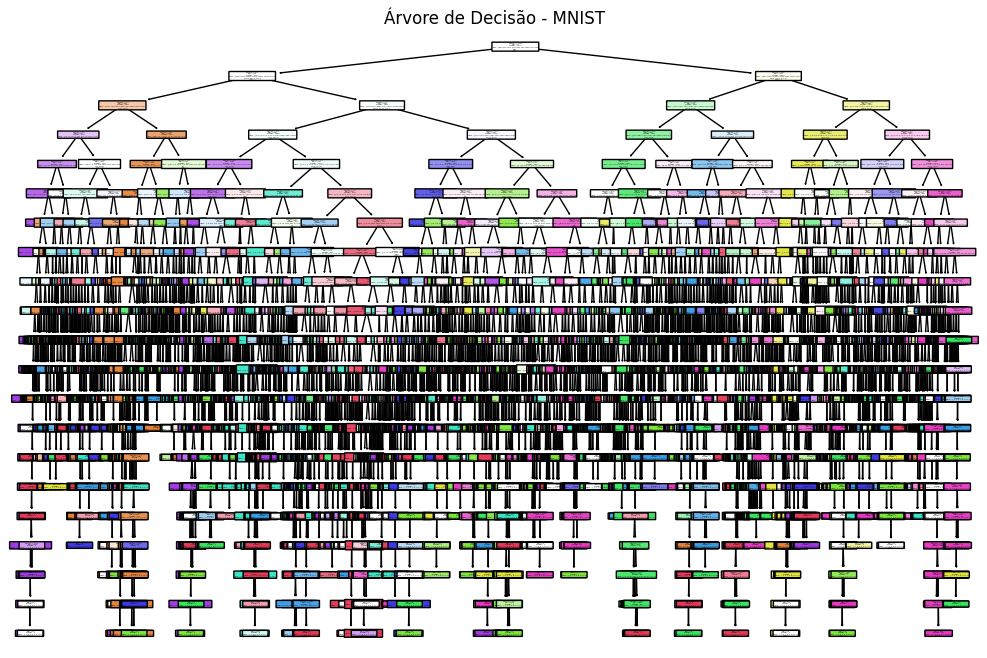

In [16]:
from sklearn.tree import export_graphviz
import graphviz

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))

plot_tree(tree_clf,
          feature_names=mnist.feature_names,
          class_names=class_names,
          filled=True,
          rounded=True)

plt.title("Árvore de Decisão - MNIST")
plt.show()
#graph.view()




In [17]:
from sklearn.model_selection import GridSearchCV

# definir espaço de hiperparâmetros a serem testados
param_grid = {
    'max_depth': [20,22],
    'min_samples_split': [6,10],
    'min_samples_leaf': [1,2]
}

# instanciar o modelo
dtc = DecisionTreeClassifier(random_state=42)

# instanciar o objeto GridSearchCV
grid_search = GridSearchCV(dtc, param_grid, cv=10, n_jobs=-1)

# treinar o modelo com a busca de parâmetros
grid_search.fit(X_train, y_train)

# imprimir os melhores parâmetros e score
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Score do modelo com os melhoress parâmetros: {grid_search.best_score_}")


Melhores parâmetros: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 6}
Score do modelo com os melhores parâmetros: 0.8685178571428571
